# Fine-Tuning Analysis

# Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Downsteam GLM

# Using Gemini Model

In [ ]:
train_df = np.load("embeddings/gemini_train_embeddings.npz")

test_df = np.load("embeddings/gemini_test_embeddings.npz")

In [4]:
# Partition Data
X_train = train_df['X']
meta_train = [train_df['y'], train_df['w']]

meta_train = pd.DataFrame({
    'ClaimNb': meta_train[0],
    'Exposure': meta_train[1]
})


X_test = test_df['X']
meta_test = [test_df['y'], test_df['w']]

meta_test = pd.DataFrame({
    'ClaimNb': meta_test[0],
    'Exposure': meta_test[1]
})

# Setup Scaler & PCA with Pandas Output
scaler = StandardScaler().set_output(transform='pandas')
pca = PCA(n_components=100).set_output(transform='pandas')

# Pipeline Execution
# TRAIN: Fit & Transform
# Scaler returns a DF with index preserved -> PCA returns a DF with index preserved
X_train_scaled = scaler.fit_transform(X_train)
X_train_pca = pca.fit_transform(X_train_scaled)

# TEST: Transform Only
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)

# Reconstruction
# Because indices are preserved, pandas aligns rows automatically.
# We can also rename columns cleanly if we want "PC1" instead of "pca0"

# Rename columns from 'pca0' to 'PC1', 'PC2'...
new_col_names = [f"PC{i+1}" for i in range(100)]
X_train_pca.columns = new_col_names
X_test_pca.columns = new_col_names

# Concatenate (Join)
final_train = pd.concat([X_train_pca, meta_train], axis=1)
final_test = pd.concat([X_test_pca, meta_test], axis=1)

print(f"Original Predictors: {len(X_train)}")
print(f"Reduced Predictors:  {X_train_pca.shape[1]}")
print(f"Final Train Shape:   {final_train.shape}")
print(final_train.head())

Original Predictors: 500000
Reduced Predictors:  100
Final Train Shape:   (500000, 102)
         PC1       PC2       PC3        PC4        PC5       PC6        PC7  \
0  62.870514  1.518155 -2.982116  -5.957392   1.868471  8.585588  11.517632   
1  19.945080  8.927476 -3.151282 -10.800955  -0.576052  7.142439 -18.704068   
2  19.995651  9.021616 -3.199520 -10.846554  -0.589172  7.175472 -18.819900   
3 -10.743790  5.903749  3.569325  -8.626901  -2.509558 -0.578815  -0.876561   
4  15.952578  2.698232 -2.170221  -8.848677 -10.090970  2.469301 -16.459459   

        PC8       PC9      PC10  ...      PC93      PC94      PC95      PC96  \
0 -2.777123 -1.033205 -3.826737  ... -0.731794  0.200273  1.539699  2.367324   
1  2.182124 -4.743923  7.908949  ...  1.027326 -0.841227  1.085693 -1.904187   
2  2.136221 -4.729541  7.905345  ...  1.029331 -0.870017  1.077257 -1.901245   
3 -4.197455  0.441616  0.386404  ...  0.859920 -0.657152 -0.087105  0.966226   
4 -2.250129  8.179672 -4.863892  ... 

In [5]:
# Extract Variance Proportions
ex_var_ratio = pca.explained_variance_ratio_
cum_var_ratio = np.cumsum(ex_var_ratio)

# Create a Summary DataFrame
df_variance = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(ex_var_ratio))],
    'Individual_Variance': ex_var_ratio*100,
    'Cumulative_Variance': cum_var_ratio*100
})

df_variance

,Component,Individual_Variance,Cumulative_Variance
0,PC1,9.236947,9.236947
1,PC2,6.165242,15.402190
2,PC3,5.636049,21.038239
3,PC4,4.725720,25.763958
4,PC5,4.133386,29.897344
...,...,...,...
95,PC96,0.108008,91.965558
96,PC97,0.107330,92.072888
97,PC98,0.103639,92.176527
98,PC99,0.102385,92.278912


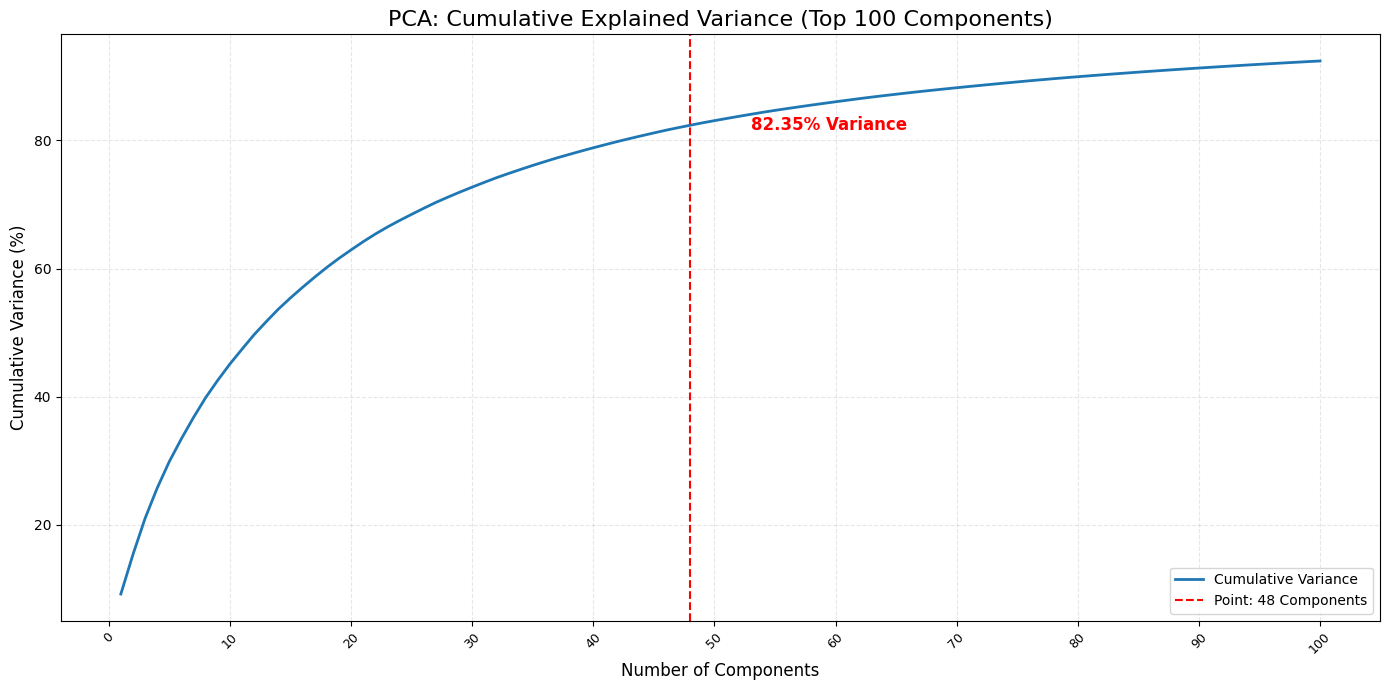

In [6]:
# Filter the data to the first 500 components
df_subset = df_variance

# Extract the variance explained by exactly 48 components
# Since Python is 0-indexed, PC48 is at index 47
var_at_48 = df_subset.iloc[47]['Cumulative_Variance']

# Set up the figure
plt.figure(figsize=(14, 7))

# Plot the cumulative variance curve
plt.plot(range(1, len(df_subset) + 1), df_subset['Cumulative_Variance'], 
         color='tab:blue', linewidth=2, label='Cumulative Variance')

# Add a vertical line at 48 components
plt.axvline(x=48, color='red', linestyle='--', linewidth=1.5, label='Point: 48 Components')

# Add a text label showing the variance explained at n=48
# We offset the x position slightly (+5) so the text doesn't sit on the line
plt.text(48 + 5, var_at_48, f'{var_at_48:.2f}% Variance', 
         color='red', fontweight='bold', fontsize=12, verticalalignment='center')

# Set x-axis ticks to show every 10th component for clarity
plt.xticks(range(0, 101, 10), rotation=45, fontsize=9)

# Formatting labels and title
plt.title('PCA: Cumulative Explained Variance (Top 100 Components)', fontsize=16)
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Variance (%)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend(loc='lower right')

# Adjust layout and show
plt.tight_layout()
#plt.savefig('var_curve.png')
plt.show()

Processing Training Size: 200
Processing Training Size: 500
Processing Training Size: 1000
Processing Training Size: 2500
Processing Training Size: 5000
Processing Training Size: 10000
Processing Training Size: 15000
Processing Training Size: 20000
Processing Training Size: 30000
Processing Training Size: 50000
Processing Training Size: 80000


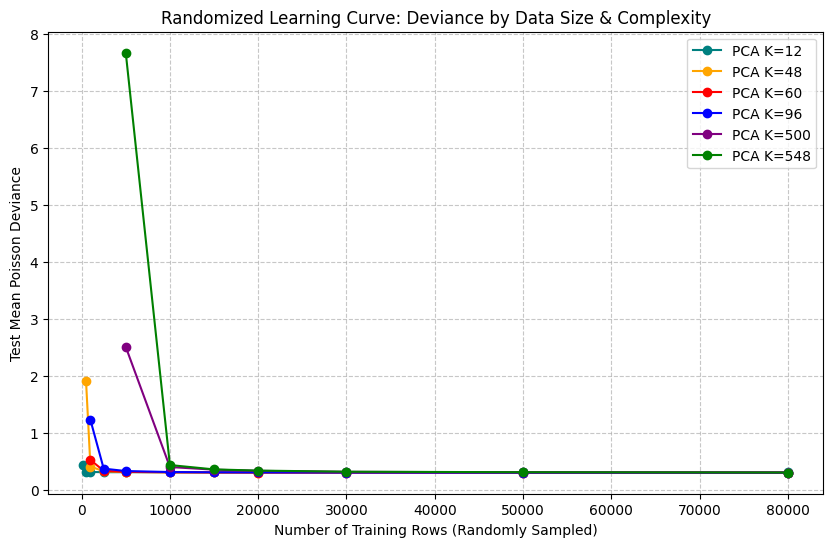

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_poisson_deviance
import statsmodels.api as sm
import gc

# -------------------------------------------------------
# Setup, Extraction & Random Shuffle
# -------------------------------------------------------
# Extracting arrays from the NpzFile 
X_raw_all = train_df['X']
y_raw_all = train_df['y']
w_raw_all = train_df['w']

# Create a random permutation of indices to shuffle X, y, and w together
np.random.seed(42)
indices = np.random.permutation(len(y_raw_all))

# Apply shuffled indices
X_train_shuffled = X_raw_all[indices]
y_train_shuffled = y_raw_all[indices]
offset_train_shuffled = w_raw_all[indices]

# Setup Test Data (Assuming test_df is also an NpzFile or similar)
X_test_raw = np.array(test_df['X'])
y_test = np.array(test_df['y'])
offset_test = np.array(test_df['w'])

# -------------------------------------------------------
# Configuration
# -------------------------------------------------------
# Use the same size logic, ensuring we don't exceed actual data size
max_available = len(y_train_shuffled)
train_sizes = [s for s in [200, 500, 1000, 2500, 5000, 10000, 15000, 20000, 30000, 50000, 80000] if s <= max_available]

start_thresholds = {
    12: 200, 48: 500, 60: 1000, 96: 1000, 500: 5000, 548: 5000
}

component_sets = [12, 48, 60, 96, 500, 548]
results_history = {k: [] for k in component_sets}

# -------------------------------------------------------
# Learning Curve Loop (Randomly Sampled)
# -------------------------------------------------------
for size in train_sizes:
    print(f"Processing Training Size: {size}")
    
    # --- Slice Data (already shuffled, so iloc-equivalent slicing is random) ---
    X_train_sub = X_train_shuffled[:size]
    y_train_sub = y_train_shuffled[:size]
    off_train_sub = offset_train_shuffled[:size]
    
    # --- Scaling ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_sub)
    X_test_scaled = scaler.transform(X_test_raw)

    # --- PCA (Dynamic Fitting per Subset) ---
    n_features = X_train_scaled.shape[1]
    max_k_possible = min(size, n_features, 548)
    
    pca = PCA(n_components=max_k_possible, random_state=42)
    X_train_pca_all = pca.fit_transform(X_train_scaled)
    X_test_pca_all = pca.transform(X_test_scaled)

    # Cleanup intermediate large objects
    del X_train_scaled, X_test_scaled, scaler, pca
    gc.collect()

    # --- Loop through component configurations ---
    for k in component_sets:
        # Check Rules
        if size < start_thresholds[k] or k > max_k_possible:
            results_history[k].append(np.nan)
            continue
            
        # Slice components
        X_train_k = X_train_pca_all[:, :k]
        X_test_k = X_test_pca_all[:, :k]
        
        try:
            glm = sm.GLM(
                endog=y_train_sub, 
                exog=sm.add_constant(X_train_k), 
                offset=np.log(off_train_sub), 
                family=sm.families.Poisson()
            )
            res = glm.fit(disp=0)
            
            # Predict and Score
            X_test_glm = sm.add_constant(X_test_k, has_constant='add')
            preds = res.predict(exog=X_test_glm, offset=np.log(offset_test))
            
            mpd = mean_poisson_deviance(y_test, preds)
            results_history[k].append(mpd)
            
        except Exception as e:
            print(f"  Failed for k={k} at size={size}: {e}")
            results_history[k].append(np.nan)

    del X_train_pca_all, X_test_pca_all
    gc.collect()

# -------------------------------------------------------
# Plotting
# -------------------------------------------------------
plt.figure(figsize=(10, 6))
colors = {12: 'teal', 48: 'orange', 60: 'red', 96: 'blue', 500: 'purple', 548: 'green'}

for k in component_sets:
    # Filter NaNs for plotting
    valid_mask = [not np.isnan(r) for r in results_history[k]]
    sizes_valid = [s for s, m in zip(train_sizes, valid_mask) if m]
    scores_valid = [r for r, m in zip(results_history[k], valid_mask) if m]
    
    plt.plot(sizes_valid, scores_valid, marker='o', linestyle='-', 
             color=colors.get(k, 'black'), label=f'PCA K={k}')

plt.title('Randomized Learning Curve: Deviance by Data Size & Complexity')
plt.xlabel('Number of Training Rows (Randomly Sampled)')
plt.ylabel('Test Mean Poisson Deviance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Learning Curves

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.metrics import mean_poisson_deviance
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Handle NpzFile and Shuffle
# -------------------------------------------------------
# Extracting arrays from the NpzFile object
X_raw_all = train_df['X']
y_raw_all = train_df['y']
w_raw_all = train_df['w']

# Create a random permutation of indices to shuffle X, y, and w together
np.random.seed(42)
indices = np.random.permutation(len(y_raw_all))

X_train_full = X_raw_all[indices]
y_train_full = y_raw_all[indices]
offset_train_full = w_raw_all[indices]

# Setup Test Data (Assuming test_df is also an NpzFile or similar)
# We convert to numpy arrays immediately for consistency
X_test_raw = np.array(test_df['X'])
y_test = np.array(test_df['y'])
offset_test = np.array(test_df['w'])

Size 500: 2.65300
Size 1077: 0.38068
Size 2320: 0.34086
Size 4999: 0.32171
Size 10772: 0.31631
Size 23207: 0.31188
Size 49999: 0.30996
Size 107721: 0.30931
Size 232079: 0.30913
Size 500000: 0.30911


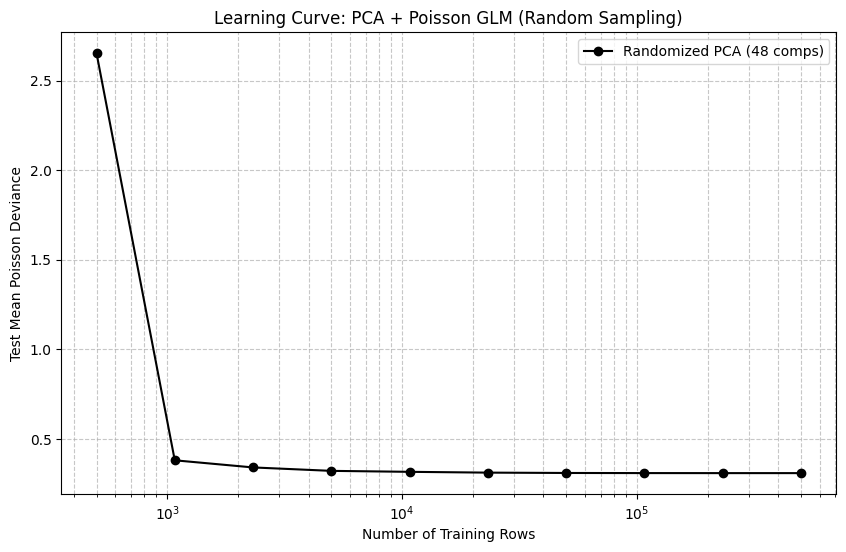

In [ ]:
# -------------------------------------------------------
# Learning Curve Loop
# -------------------------------------------------------
max_rows = len(y_train_full)
# Ensure we don't exceed actual data size
train_sizesr = np.geomspace(500, min(500000, max_rows), num=10, dtype=int)
deviancesr_2 = []
n_components = 48 

for size in train_sizesr:
    # Slice from the SHUFFLED numpy arrays
    X_train_sub_raw = X_train_full[:size]
    y_train_sub = y_train_full[:size]
    off_train_sub = offset_train_full[:size]
    
    try:
        # Fit PCA on the current training subset only
        pca = PCA(n_components=n_components)
        X_train_pca = pca.fit_transform(X_train_sub_raw)
        
        # Transform the FIXED Test set using the PCA fitted on this subset
        X_test_pca = pca.transform(X_test_raw)
        
        # Add constants for Statsmodels
        X_train_glm = sm.add_constant(X_train_pca)
        X_test_glm = sm.add_constant(X_test_pca, has_constant='add')
        
        # Fit GLM
        glm = sm.GLM(
            endog=y_train_sub, 
            exog=X_train_glm, 
            offset=np.log(off_train_sub), 
            family=sm.families.Poisson()
        )
        results = glm.fit()
        
        # Predict on transformed Test Set
        preds = results.predict(exog=X_test_glm, offset=np.log(offset_test))
        
        # Score
        mpd = mean_poisson_deviance(y_test, preds)
        deviancesr_2.append(mpd)
        print(f"Size {size}: {mpd:.5f}")
        
    except Exception as e:
        print(f"Size {size} failed: {e}")
        deviancesr_2.append(None)

# -------------------------------------------------------
# Plotting 
# -------------------------------------------------------
plt.figure(figsize=(10, 6))

# Filter out potential None values for the plot
valid_indices = [i for i, v in enumerate(deviancesr_2) if v is not None]
plt.plot(
    np.array(train_sizesr)[valid_indices], 
    np.array(deviancesr_2)[valid_indices], 
    marker='o', color='black', label=f'Randomized PCA ({n_components} comps)'
)

plt.xscale('log')
plt.title('Learning Curve: PCA + Poisson GLM (Random Sampling)')
plt.xlabel('Number of Training Rows')
plt.ylabel('Test Mean Poisson Deviance')
plt.grid(True, linestyle='--', alpha=0.7, which='both')
plt.legend()
plt.show()

# Effect of Embedding Dimensionality

Starting Grid Analysis for 8 sizes and 8 component counts...
Processing Training Size: 500...


/home/dkusmenko/.local/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/dkusmenko/.local/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/dkusmenko/.local/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/dkusmenko/.local/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnin

Processing Training Size: 1000...


/home/dkusmenko/.local/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/dkusmenko/.local/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/dkusmenko/.local/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/dkusmenko/.local/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnin

Processing Training Size: 2000...
Processing Training Size: 5000...
Processing Training Size: 10000...
Processing Training Size: 20000...
Processing Training Size: 40000...
Processing Training Size: 80000...

--- Test Mean Poisson Deviance Grid ---
                 6         12        24        48            96   \
Train_Size                                                         
500         0.322401  0.325087  0.393508  1.917054  5.282466e+21   
1000        0.322434  0.322184  0.350130  0.417327  1.232435e+00   
2000        0.317202  0.320278  0.326333  0.342466  3.896445e-01   
5000        0.318656  0.318186  0.318634  0.321514  3.382025e-01   
10000       0.317379  0.316989  0.316060  0.316596  3.209592e-01   
20000       0.316165  0.315337  0.313339  0.312317  3.138882e-01   
40000       0.315445  0.313873  0.311782  0.310132  3.105438e-01   
80000       0.315214  0.313572  0.311275  0.309261  3.087948e-01   

                     192           384           768  
Train_Size     

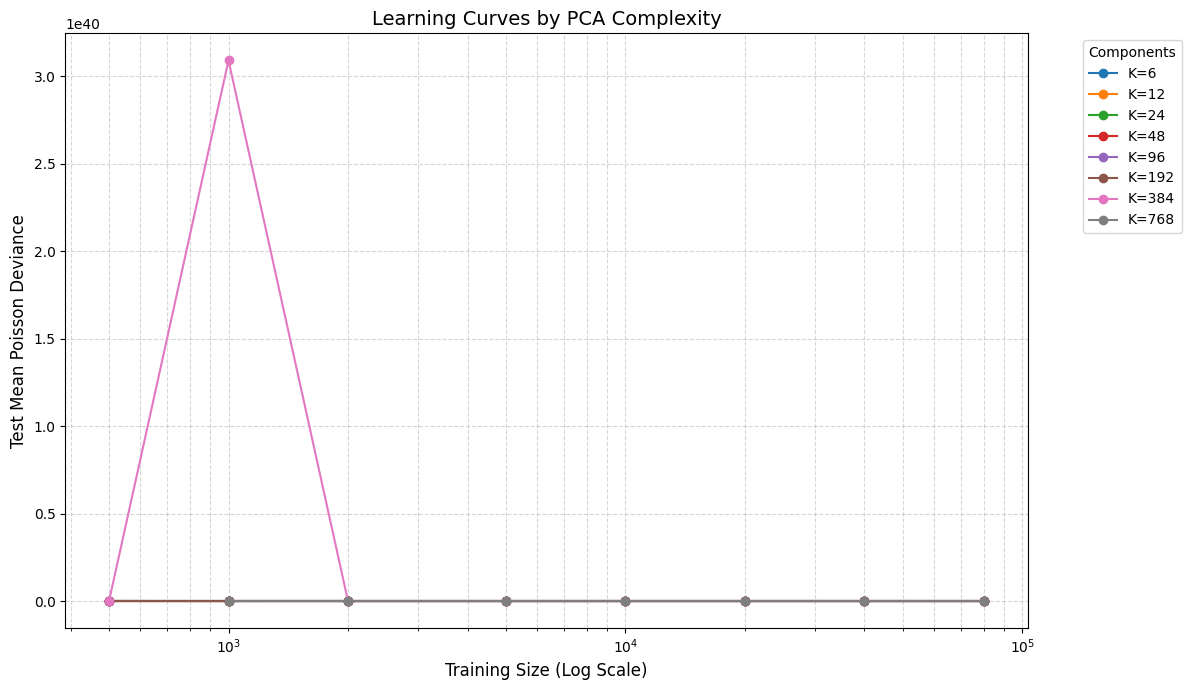

In [ ]:
# -------------------------------------------------------
# Multi-Complexity Grid Analysis (Deviance Table)
# -------------------------------------------------------
import gc

# Define the Grid
component_grid = [6, 12, 24, 48, 96, 192, 384, 768]
size_grid = [500, 1000, 2000, 5000, 10000, 20000, 40000, 80000]

# Initialize storage for results
grid_results = {k: [] for k in component_grid}

print(f"Starting Grid Analysis for {len(size_grid)} sizes and {len(component_grid)} component counts...")

for size in size_grid:
    # Ensure we don't request more rows than available in the shuffled training set
    if size > len(y_train_full):
        print(f"Skipping size {size} (insufficient data).")
        for k in component_grid:
            grid_results[k].append(np.nan)
        continue
        
    print(f"Processing Training Size: {size}...")
    
    # Subset shuffled data
    X_train_sub = X_train_full[:size]
    y_train_sub = y_train_full[:size]
    off_train_sub = offset_train_full[:size]
    
    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_sub)
    X_test_scaled = scaler.transform(X_test_raw)
    
    n_features = X_train_scaled.shape[1]
    
    # Fit PCA once for the maximum needed components to save time
    max_k_requested = max(component_grid)
    max_k_possible = min(size, n_features, max_k_requested)
    
    pca = PCA(n_components=max_k_possible, random_state=42)
    X_train_pca_all = pca.fit_transform(X_train_scaled)
    X_test_pca_all = pca.transform(X_test_scaled)
    
    # Iterate through Component configurations
    for k in component_grid:
        # Check if this component count is mathematically possible for the current size/features
        if k > max_k_possible:
            grid_results[k].append(np.nan)
            continue
            
        # Slice the first K components
        X_train_k = X_train_pca_all[:, :k]
        X_test_k = X_test_pca_all[:, :k]
        
        try:
            # Fit Poisson GLM
            glm = sm.GLM(
                endog=y_train_sub, 
                exog=sm.add_constant(X_train_k), 
                offset=np.log(off_train_sub), 
                family=sm.families.Poisson()
            )
            res = glm.fit(disp=0)
            
            # Predict on Test set
            X_test_glm = sm.add_constant(X_test_k, has_constant='add')
            preds = res.predict(exog=X_test_glm, offset=np.log(offset_test))
            
            # Calculate and store Poisson Deviance
            mpd = mean_poisson_deviance(y_test, preds)
            grid_results[k].append(mpd)
            
        except Exception as e:
            grid_results[k].append(np.nan)

    # Memory cleanup
    del X_train_scaled, X_test_scaled, X_train_pca_all, X_test_pca_all
    gc.collect()

# Summary Table
df_grid_deviance = pd.DataFrame(grid_results, index=size_grid)
df_grid_deviance.index.name = 'Train_Size'
print("\n--- Test Mean Poisson Deviance Grid ---")
print(df_grid_deviance)

# Optional: Visualize the Grid
plt.figure(figsize=(12, 7))
for k in component_grid:
    # Plot only if there are valid results for this K
    if not df_grid_deviance[k].isna().all():
        plt.plot(df_grid_deviance.index, df_grid_deviance[k], marker='o', label=f'K={k}')

plt.xscale('log')
plt.title('Learning Curves by PCA Complexity', fontsize=14)
plt.xlabel('Training Size (Log Scale)', fontsize=12)
plt.ylabel('Test Mean Poisson Deviance', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(title='Components', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [5]:
df_grid_deviance

,6,12,24,48,96,192,384,768
Train_Size,,,,,,,,
500,0.322401,0.325087,0.393508,1.917054,5.282466e+21,5.249864e+36,3.477676e+23,NaN
1000,0.322434,0.322184,0.350130,0.417327,1.232435e+00,4.053064e+21,3.090701e+40,1.785918e+33
2000,0.317202,0.320278,0.326333,0.342466,3.896445e-01,3.796255e+00,2.563212e+32,1.061439e+32
5000,0.318656,0.318186,0.318634,0.321514,3.382025e-01,3.872284e-01,1.923579e+00,4.724315e+21
10000,0.317379,0.316989,0.316060,0.316596,3.209592e-01,3.393672e-01,3.684785e-01,5.947762e-01
20000,0.316165,0.315337,0.313339,0.312317,3.138882e-01,3.204088e-01,3.306668e-01,3.721830e-01
40000,0.315445,0.313873,0.311782,0.310132,3.105438e-01,3.126433e-01,3.164628e-01,3.284131e-01
80000,0.315214,0.313572,0.311275,0.309261,3.087948e-01,3.094331e-01,3.104323e-01,3.147700e-01
